In [ ]:
import numpy as np
from matplotlib import pyplot as plt

<ins> Build a fucntion to update the centrods

In [ ]:
def update_centroids(X,k,labels):
    ncol = X.shape[1]
    centroids = np.zeros(shape = (k,ncol))
    for cluster in range(k):
        centroids[cluster,:] = np.mean(X[labels == cluster,:],axis =0)
    return(centroids)

    

In [ ]:
#Compute the mahalanbis distence of two given datapoints
def mahalanobis_distance(point1,point2):
    import numpy as np
    from scipy.linalg import sqrtm

     
    dev = (point1 - point2)
    dev_transpose = dev.T
    cov = np.cov(X, rowvar=False)
    cov_inverse = np.linalg.inv(cov)
    
    mah_dist = np.sqrt(np.dot(np.dot(dev, cov_inverse), dev.T))
    return(mah_dist)
def compute_distances_from_centroids_with_mahalanobis(X, centroids):  
    nrow = X.shape[0]  
    
    mah_dist = np.zeros(shape=(nrow,centroids.shape[0]))
    for i, centroid in enumerate(centroids):
        #a = np.apply_along_axis(mahalanobis_distance, axis=1, arr = X, point2 = centroid)
        mah_dist[:,i] = np.apply_along_axis(mahalanobis_distance, axis=1, arr = X, point2 = centroid)
    labels = np.argmin(mah_dist, axis = 1)
    #return(eudist)
    return(labels)

In [ ]:
#Compute the manhatan distence of two given datapoints

def manhatan_distance(point1,point2):
    import numpy as np
    dist = 0
    for i in range(len(point1)):
        dist = dist + abs(point1[i] - point2[i])
    return(dist)
    

def compute_distances_from_centroids_with_manhatan(X, centroids):  
    nrow = X.shape[0]
    manh_dist = np.zeros(shape=(nrow,centroids.shape[0]))
    for i, centroid in enumerate(centroids):
        #a = np.apply_along_axis(mahalanobis_distance, axis=1, arr = X, point2 = centroid)
        manh_dist[:,i] = np.apply_along_axis(manhatan_distance, axis=1, arr = X, point2 = centroid)
    labels = np.argmin(manh_dist, axis = 1)
    #return(eudist)
    return(labels)

In [ ]:
# Compute the euclidean distance of datapoints from centroids
def compute_distances_from_centroids_with_euclidean(X,centroids):
    from scipy.spatial.distance import cdist
    eudist = cdist(X, centroids, metric='euclidean')
    labels = np.argmin(eudist, axis = 1)
    #return(eudist)
    return(labels)

<ins> Implement the kmeans algorithm

In [ ]:
def kmeans(X,k,max_iterations, distance):
    from sklearn.metrics import silhouette_score
    import time
    start_time = time.time()
    
    minimums = np.min(X,axis = 0)
    maximums = np.max(X, axis = 0)
    nrow, ncol = X.shape
    iteration = 0
    
    centroids = np.zeros(shape = (k,ncol))
    for i in range(k):
        centroids[i,:] = np.random.uniform(minimums, maximums, size=(1,ncol))


    if distance == 'euclidean':
        while iteration <= max_iterations:
            labels = compute_distances_from_centroids_with_euclidean(X, centroids)
            new_centroids = update_centroids(X,k,labels)
            if np.array_equal(new_centroids, centroids):
                #print('{} iterations completed in total.'.format(iteration))
                break
            else:
                centroids = new_centroids
                #print(iteration)
                iteration+=1
    elif distance == 'manhattan':
        while iteration <= max_iterations:
            labels = compute_distances_from_centroids_with_manhatan(X, centroids)
            new_centroids = update_centroids(X,k,labels)
            if np.array_equal(new_centroids, centroids):
                #print('{} iterations completed in total.'.format(iteration))
                break
            else:
                centroids = new_centroids
                #print(iteration)
                iteration+=1
    
    elif distance == 'mahalanobis':
        while iteration <= max_iterations:
            labels = compute_distances_from_centroids_with_mahalanobis(X, centroids)
            new_centroids = update_centroids(X,k,labels)
            if np.array_equal(new_centroids, centroids):
                #print('{} iterations completed in total.'.format(iteration))
                break
            else:
                centroids = new_centroids
                #print(iteration)
                iteration+=1
    else:
        raise ValueError('Input Error. Distance should be Euclidean, manhattan or mahalanobis')
    


    score = silhouette_score(X, labels)
    end_time = time.time()
    run_time = end_time - start_time
    
    #print('The silhouette score is : {:.2f}'.format(score))
    #print('Clustering took {:.2f} seconds.'.format(run_time))
    return(centroids,labels, score)

<ins> Generate a dataset to test the algorithm

[]

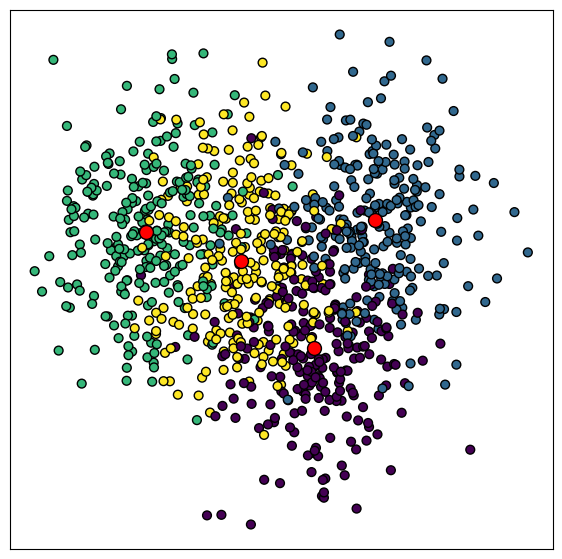

In [ ]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=1000,n_features=10,centers=4,cluster_std=3.0,random_state=0)
#X = np.random.rand(1000, 2)
k_means_result = kmeans(X,4,50,'manhattan')
centroids = k_means_result[0]
k_means_labels = k_means_result[1]
from matplotlib import pyplot as plt

   

#Plot the results
fig, ax = plt.subplots(1,1,figsize = (7, 7))

ax.scatter(X[:,0], X[:,1], marker = 'o', cmap='viridis', edgecolors='k', c = k_means_labels, s=40)
ax.scatter(centroids[:,0], centroids[:,1],marker='o', c = 'red', s=100,edgecolors='black')
ax.set_xticks([])
ax.set_yticks([])